In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Scraped_Data.csv.zip")

print("Shape:", df.shape)
df.head()

Shape: (27900, 91)


,exactPrice,sqftPrice,securityDeposit,propertyType,postedOn,noOfLifts,maintenanceChargesFrequency,maintenanceCharges,locality,furnishing,...,Cafeteria_Or_Food_Court,CCTV_Camera,Barbeque_Pit,Bar_Or_Lounge,Banquet_Hall,Bank__And__ATM,Arts__And__Craft_Studio,Air_Conditioned,Activity_Deck4,AEROBICS_ROOM
0,240000,171,9,Multistorey Apartment,"Jun 20, '23",9.0,9,9,Danapur,Semi-Furnished,...,1,0,0,1,1,0,0,0,0,0
1,12000,12,12000,Multistorey Apartment,"Jun 19, '23",1.0,Monthly,1500,9,Semi-Furnished,...,9,9,9,9,9,9,9,9,9,9
2,17000,7,9,Residential House,"Jun 21, '23",9.0,9,9,Phase 1 Ashiana Nagar,Semi-Furnished,...,9,9,9,9,9,9,9,9,9,9
3,5000,9,9,Residential House,"Jun 23, '23",9.0,9,9,Kumhrar,Furnished,...,9,9,9,9,9,9,9,9,9,9
4,12000,9,24000,Multistorey Apartment,"Jun 24, '23",1.0,Monthly,500,Kumhrar,Unfurnished,...,9,9,9,9,9,9,9,9,9,9


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27900 entries, 0 to 27899
Data columns (total 91 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   exactPrice                            27900 non-null  int64  
 1   sqftPrice                             27900 non-null  int64  
 2   securityDeposit                       27900 non-null  int64  
 3   propertyType                          27900 non-null  object 
 4   postedOn                              27900 non-null  object 
 5   noOfLifts                             27445 non-null  float64
 6   maintenanceChargesFrequency           27900 non-null  object 
 7   maintenanceCharges                    27900 non-null  int64  
 8   locality                              27900 non-null  object 
 9   furnishing                            27900 non-null  object 
 10  flrNum                                27900 non-null  object 
 11  firstMonthCharg

In [3]:
# Check unique values in few amenity columns

amenity_cols = [
    "Gymnasium",
    "Swimming_Pool",
    "Club_House",
    "Lift",
    "Security"
]

for col in amenity_cols:
    print(col, df[col].unique())

Gymnasium [1 9 0]
Swimming_Pool [1 9 0]
Club_House [1 9 0]
Lift [0 9 1]
Security [1 9 0]


In [4]:
df["sqftPrice"].corr(df["exactPrice"])

np.float64(0.12780166785600364)

In [5]:
# Identify amenity columns (binary type with 0,1,9)
amenity_cols = []

for col in df.columns:
    if set(df[col].unique()).issubset({0,1,9}):
        amenity_cols.append(col)

print("Amenity Columns Count:", len(amenity_cols))

Amenity Columns Count: 66


In [6]:
# Replace 9 with NaN in amenity columns
df[amenity_cols] = df[amenity_cols].replace(9, pd.NA)

# Now fill NaN with 0
df[amenity_cols] = df[amenity_cols].fillna(0)

# Verify
for col in amenity_cols[:5]:
    print(col, df[col].unique())

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15940\3056906362.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[amenity_cols] = df[amenity_cols].fillna(0)


Water_Storage [1 0]
Waste_Disposal [0 1]
Visitor_Parking [1 0]
Vaastu_Compliant [1 0]
Swimming_Pool [1 0]


In [7]:
cols_to_drop = ["sqftPrice", "URLs"]

df = df.drop(columns=cols_to_drop)

df.shape

(27900, 89)

In [8]:
df["city"].isnull().sum()

np.int64(1)

In [9]:
df = df.dropna(subset=["city"])

In [10]:
df.shape

(27899, 89)

In [11]:
df["city"].isnull().sum()

np.int64(0)

In [12]:
df["exactPrice"].describe()

count    2.789900e+04
mean     5.427727e+06
std      2.699633e+07
min      9.000000e+00
25%      1.300000e+04
50%      3.000000e+04
75%      5.273000e+06
max      3.250000e+09
Name: exactPrice, dtype: float64

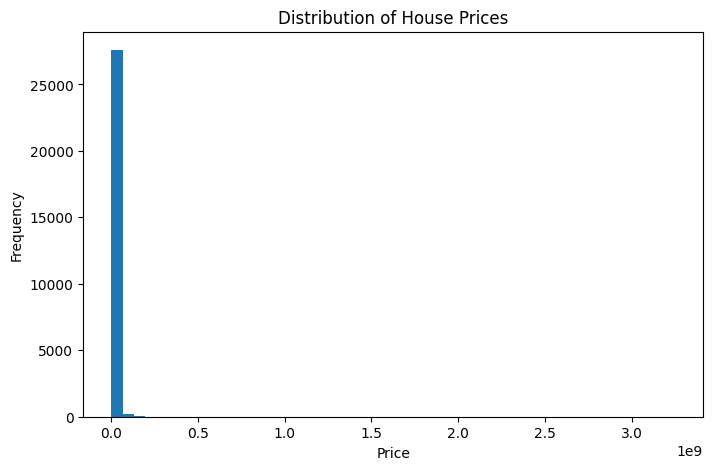

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["exactPrice"], bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [14]:
# Check quantiles
lower = df["exactPrice"].quantile(0.01)
upper = df["exactPrice"].quantile(0.99)

print("Lower 1%:", lower)
print("Upper 99%:", upper)

# Filter dataset
df = df[(df["exactPrice"] >= lower) & (df["exactPrice"] <= upper)]

print("New Shape:", df.shape)

Lower 1%: 9.0
Upper 99%: 70000000.0
New Shape: (27633, 89)


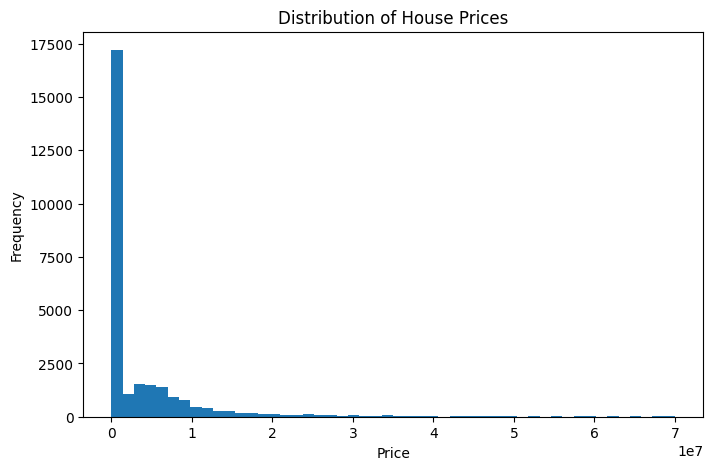

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["exactPrice"], bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [16]:
import numpy as np

df["log_price"] = np.log1p(df["exactPrice"])

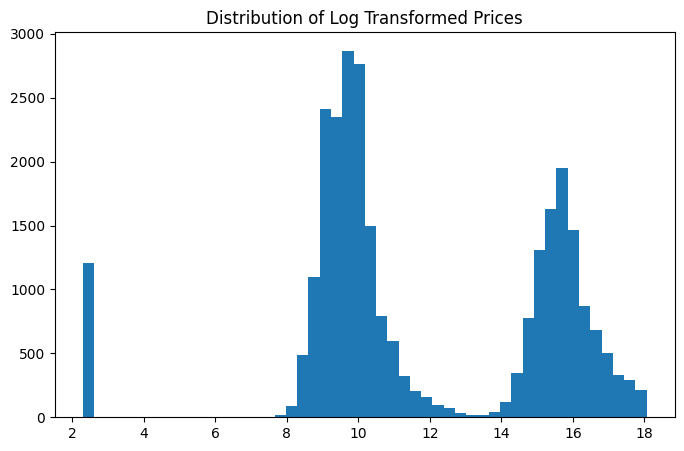

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["log_price"], bins=50)
plt.title("Distribution of Log Transformed Prices")
plt.show()

In [18]:
df["RentOrSale"].value_counts()

RentOrSale
Rent    16025
Sale    11578
9          30
Name: count, dtype: int64

In [19]:
df = df[df["RentOrSale"] != 9]

In [20]:
df_sale = df[df["RentOrSale"] == "Sale"].copy()

print(df_sale.shape)

(11578, 90)


In [21]:
df_sale = df_sale.drop(columns=["RentOrSale"])
df_sale.shape

(11578, 89)

In [22]:
missing = df_sale.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(15)

noOfLifts    124
dtype: int64

In [23]:
median_lifts = df_sale["noOfLifts"].median()

df_sale["noOfLifts"] = df_sale["noOfLifts"].fillna(median_lifts)

df_sale["noOfLifts"].isnull().sum()

np.int64(0)

In [24]:
# Target variable
y = df_sale["log_price"]

# Drop target columns from features
X = df_sale.drop(columns=["exactPrice", "log_price"])

In [25]:
X = X.drop(columns=["Lat", "Long"])

In [26]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

Numeric features: 75
Categorical features: 10


In [27]:
# Identify amenity columns again
amenity_cols = [col for col in X.columns if X[col].isin([0,1]).all()]

print("Amenity columns:", len(amenity_cols))

Amenity columns: 66


In [28]:
X["luxury_score"] = X[amenity_cols].sum(axis=1)

In [29]:
X = X.drop(columns=amenity_cols)

In [30]:
for col in categorical_cols:
    print(col, X[col].nunique())

propertyType 6
postedOn 170
maintenanceChargesFrequency 6
locality 1602
furnishing 4
flrNum 53
facing 9
city 10
carpetAreaUnit 8
brokerage 11


In [31]:
X = X.drop(columns=["locality"])

In [32]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Updated Numeric:", len(numeric_cols))
print("Updated Categorical:", len(categorical_cols))

Updated Numeric: 10
Updated Categorical: 9


In [ ]:

# FEATURE STRUCTURING 


# 1. Target
y = df_sale["log_price"]

# 2. Drop target & leakage columns
X = df_sale.drop(columns=["exactPrice", "log_price", "sqftPrice"], errors="ignore")

# 3. Drop columns we won't use
drop_cols = ["Lat", "Long", "locality", "postedOn"]
X = X.drop(columns=[col for col in drop_cols if col in X.columns])

# 4. Create luxury score from amenity columns (0/1 columns)
amenity_cols = [col for col in X.columns if X[col].isin([0,1]).all()]
X["luxury_score"] = X[amenity_cols].sum(axis=1)

# 5. Drop individual amenity columns
X = X.drop(columns=amenity_cols)

# 6. Recalculate feature types
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Final Shape:", X.shape)
print("Numeric Features:", len(numeric_cols))
print("Categorical Features:", len(categorical_cols))
print("\nCategorical Columns:", categorical_cols)

Final Shape: (11578, 18)
Numeric Features: 10
Categorical Features: 8

Categorical Columns: ['propertyType', 'maintenanceChargesFrequency', 'furnishing', 'flrNum', 'facing', 'city', 'carpetAreaUnit', 'brokerage']


In [34]:

# TRAIN TEST SPLIT + ENCODING + BASELINE


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Column Transformer (Encoding categorical features)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# 3. Pipeline with Linear Regression
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

# 4. Train Model
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation (convert back from log scale)
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

MAE: 33059677.61
RMSE: 801502606.36
R2 Score: 0.4212


In [ ]:

# RANDOM FOREST MODEL


from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_pred_rf_actual = np.expm1(y_pred_rf)

mae_rf = mean_absolute_error(y_test_actual, y_pred_rf_actual)
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf_actual))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", round(mae_rf, 2))
print("Random Forest RMSE:", round(rmse_rf, 2))
print("Random Forest R2:", round(r2_rf, 4))

Random Forest MAE: 3180506.17
Random Forest RMSE: 6577454.22
Random Forest R2: 0.8707


In [ ]:

y_train_pred_rf = rf_model.predict(X_train)
r2_train_rf = r2_score(y_train, y_train_pred_rf)

print("Train R2:", round(r2_train_rf, 4))
print("Test R2:", round(r2_rf, 4))

Train R2: 0.9533
Test R2: 0.8707


In [ ]:

# FEATURE IMPORTANCE (Random Forest)


import pandas as pd

# Get feature names after encoding
feature_names = rf_model.named_steps["preprocessing"].get_feature_names_out()

importances = rf_model.named_steps["regressor"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
107,remainder__totalFlrNum,0.385715
112,remainder__luxury_score,0.223621
63,cat__flrNum_9,0.185077
109,remainder__bedrooms,0.035634
110,remainder__bathrooms,0.026418
108,remainder__carpetArea,0.019258
12,cat__furnishing_9,0.018923
82,cat__city_Lucknow,0.010594
111,remainder__balconies,0.008794
83,cat__city_Mumbai,0.008073


In [ ]:

# XGBOOST MODEL


from xgboost import XGBRegressor

xgb_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

# Convert back from log
y_pred_xgb_actual = np.expm1(y_pred_xgb)

mae_xgb = mean_absolute_error(y_test_actual, y_pred_xgb_actual)
rmse_xgb = np.sqrt(mean_squared_error(y_test_actual, y_pred_xgb_actual))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost MAE:", round(mae_xgb, 2))
print("XGBoost RMSE:", round(rmse_xgb, 2))
print("XGBoost R2:", round(r2_xgb, 4))

XGBoost MAE: 3423757.0
XGBoost RMSE: 7572867.7
XGBoost R2: 0.8634


In [39]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

# SAVE FINAL MODEL


import joblib

joblib.dump(rf_model, "../models/final_real_estate_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [ ]:

# EXPORT ACTUAL VS PREDICTED (NOTEBOOK)


import pandas as pd

actual_vs_pred = pd.DataFrame({
    "actual_price": y_test_actual,
    "predicted_price": y_pred_rf_actual
})

actual_vs_pred.to_csv("../data/processed/actual_vs_predicted.csv", index=False)

print("Actual vs Predicted exported successfully.")


Actual vs Predicted exported successfully.


In [ ]:

# EXPORT FEATURE IMPORTANCE


rf = rf_model.named_steps["regressor"]
feature_names = rf_model.named_steps["preprocessing"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature_name": feature_names,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.to_csv("../data/processed/feature_importance.csv", index=False)

print("Feature importance exported successfully.")

Feature importance exported successfully.
